In [4]:
# Install required packages (run once)
!uv pip install -q scikit-learn matplotlib numpy pandas

# Module 1: Foundations of AI and Machine Learning

## Learning Objectives
By the end of this module, you will be able to:
- Understand the difference between rule-based programming and machine learning
- Distinguish between supervised and unsupervised learning
- Understand the basic ML development workflow
- Grasp key concepts: data preprocessing, features, overfitting, and evaluation metrics

---

## 1. Rule-Based Programming vs Machine Learning

### Traditional Programming (Rule-Based)
In traditional programming, we explicitly write rules to solve problems:

```
Input + Rules → Output
```

**Example:** A spam filter with explicit rules:
- If email contains "lottery winner" → spam
- If email contains "Nigerian prince" → spam
- If sender is in contacts → not spam

### Machine Learning Approach
Instead of writing rules, we let the computer **learn patterns** from data:

```
Input + Expected Output → Learned Rules (Model)
```

**Example:** A spam filter that learns from thousands of labeled emails what patterns indicate spam.

In [1]:
# Rule-Based Example: Temperature Classification
def classify_temperature_rules(temp_celsius):
    """Traditional rule-based approach"""
    if temp_celsius < 0:
        return "freezing"
    elif temp_celsius < 15:
        return "cold"
    elif temp_celsius < 25:
        return "comfortable"
    elif temp_celsius < 35:
        return "warm"
    else:
        return "hot"

# Test the rule-based system
test_temps = [-5, 10, 22, 30, 40]
for temp in test_temps:
    print(f"{temp}°C → {classify_temperature_rules(temp)}")

-5°C → freezing
10°C → cold
22°C → comfortable
30°C → warm
40°C → hot


### When to Use ML vs Rule-Based?

| Use Rule-Based When | Use ML When |
|---------------------|-------------|
| Rules are clear and well-defined | Patterns are complex or unknown |
| Domain is stable (rules don't change) | Data evolves over time |
| Limited edge cases | Too many rules to enumerate |
| Explainability is critical | Performance matters more than interpretability |

**Generative AI Context:** Large Language Models (LLMs) are the ultimate ML approach - they learn language patterns from billions of text examples rather than explicitly coded grammar rules.

---

## 2. Supervised vs Unsupervised Learning

### Supervised Learning
The model learns from **labeled examples** - we provide both the input AND the correct answer.

| Input (Features) | Output (Label) |
|------------------|----------------|
| Email text | Spam/Not Spam |
| House size, location | Price |
| Image of animal | Cat/Dog |

**Types:**
- **Classification:** Predict a category (spam/not spam, cat/dog)
- **Regression:** Predict a continuous value (price, temperature)

### Unsupervised Learning
The model finds **patterns without labels** - we only provide input data.

**Types:**
- **Clustering:** Group similar items (customer segments)
- **Dimensionality Reduction:** Compress data while preserving structure
- **Anomaly Detection:** Find unusual patterns

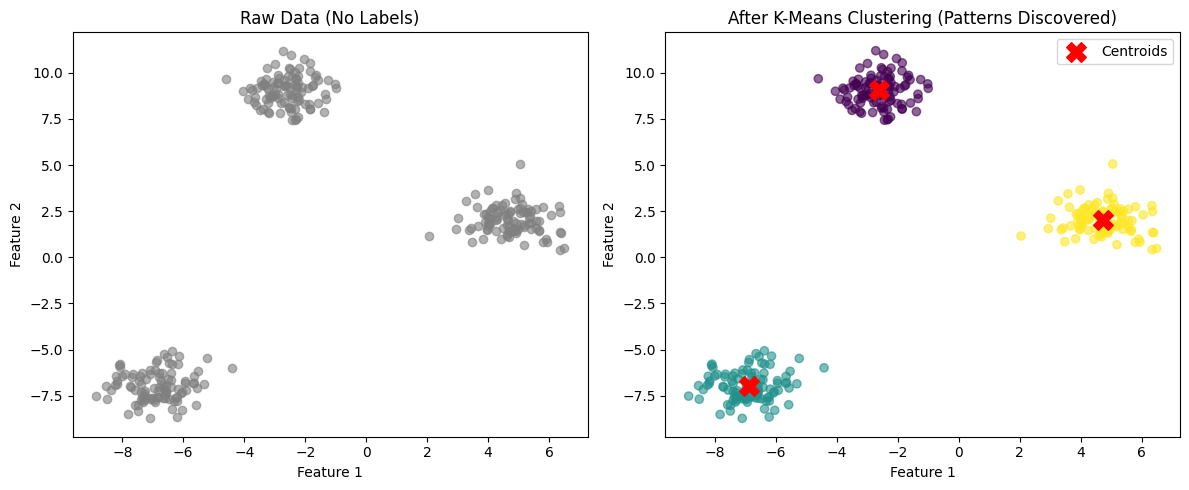


💡 Key insight: The algorithm found 3 groups WITHOUT being told what the groups are!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_iris
from sklearn.cluster import KMeans

# Generate sample data for clustering
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

# Unsupervised Learning: K-Means Clustering (no labels provided!)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], c='gray', alpha=0.6)
axes[0].set_title('Raw Data (No Labels)', fontsize=12)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

axes[1].scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.6)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                c='red', marker='X', s=200, label='Centroids')
axes[1].set_title('After K-Means Clustering (Patterns Discovered)', fontsize=12)
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n💡 Key insight: The algorithm found 3 groups WITHOUT being told what the groups are!")

---

## 3. The Machine Learning Workflow

```
┌─────────────┐   ┌─────────────┐   ┌─────────────┐   ┌─────────────┐   ┌─────────────┐
│   Collect   │ → │   Clean &   │ → │   Feature   │ → │   Train     │ → │  Evaluate   │
│    Data     │   │  Preprocess │   │ Engineering │   │   Model     │   │   Model     │
└─────────────┘   └─────────────┘   └─────────────┘   └─────────────┘   └─────────────┘
```

### Step 1: Data Collection
- Gather relevant data for your problem
- More quality data → better models

### Step 2: Data Preprocessing
- Handle missing values
- Remove duplicates
- Normalize/standardize numerical features
- Encode categorical variables

### Step 3: Feature Engineering
- Select relevant features
- Create new features from existing ones
- Transform features for better model performance

### Step 4: Model Training
- Split data into training and test sets
- Choose an algorithm
- Train the model on training data

### Step 5: Model Evaluation
- Test on held-out data
- Calculate performance metrics
- Iterate and improve

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load the famous Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

print("Dataset Overview:")
print(f"   Features: {iris.feature_names}")
print(f"   Classes: {iris.target_names}")
print(f"   Samples: {X.shape[0]}, Features per sample: {X.shape[1]}")

# Step 1: Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nData Split: {len(X_train)} training, {len(X_test)} test samples")

# Step 2: Preprocess - Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features standardized (mean=0, std=1)")

# Step 3: Train the model
model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)
print("Model trained!")

# Step 4: Evaluate
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.2%}")

# Print full classification report (precision, recall, F1 per class)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Note: Iris is a linearly separable dataset — 100% accuracy is common and expected here.
# In practice, achieving 100% accuracy should always be examined carefully:
# it can indicate data leakage, an overly easy problem, or overfitting on a small test set.
# On real-world data, perfect accuracy is often a red flag.

Dataset Overview:
   Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
   Classes: ['setosa' 'versicolor' 'virginica']
   Samples: 150, Features per sample: 4

Data Split: 120 training, 30 test samples
Features standardized (mean=0, std=1)
Model trained!

Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



---

## 📊 Reading Your Results: Classification Report Explained

If you just ran the cell above and saw output like this, let's break it down so it actually means something:

```
Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30
```

### What does each number mean?

#### `support` — How many examples of each class were in the test set?
The rightmost column tells you how many actual flowers of each type existed in your test data. Here, 10 setosa, 9 versicolor, and 11 virginica flowers were tested. This total (30) matches the 20% test split from 150 samples.

---

#### `precision` — "When the model predicted this class, how often was it right?"

> Precision = True Positives ÷ (True Positives + False Positives)

Imagine the model shouts "This is a setosa!" 10 times. If 10 of those were actually setosa and 0 were wrong predictions — precision is 1.00 (100%).

A **low precision** means the model is trigger-happy — it calls things setosa when they aren't.

Example: Marketing spam filter. Low precision = lots of good emails land in spam.

---

#### `recall` — "Of all the actual class X flowers, how many did the model find?"

> Recall = True Positives ÷ (True Positives + False Negatives)

If there were 10 actual setosa flowers in the test set, and the model correctly labeled all 10 — recall is 1.00.

A **low recall** means the model misses a lot of real cases — it's too cautious.

Example: Cancer screening. Low recall = real cancer cases get missed (dangerous!).

---

#### `f1-score` — The balance between precision and recall

> F1 = 2 × (Precision × Recall) ÷ (Precision + Recall)

F1 is the harmonic mean of precision and recall. It's useful when the two are in tension — a model that always predicts "positive" has 100% recall but terrible precision; F1 penalizes that imbalance.

**Rule of thumb:**
- Use **accuracy** when classes are balanced and all errors cost the same
- Use **F1** when one type of error is worse than the other (e.g., missing a disease diagnosis)

---

#### `macro avg` vs `weighted avg`

| | What it does |
|---|---|
| **macro avg** | Averages the metrics for each class equally — treats all classes as equally important |
| **weighted avg** | Averages by class size (support) — classes with more examples count more |

When your classes are *imbalanced* (e.g., 1,000 examples of class A vs. 10 of class B), macro avg gives you a fairer picture of performance on the minority class.

---

### 🤔 Wait — 100% accuracy? Is that too good to be true?

It can be! On the **Iris dataset**, 100% is normal because:
1. The dataset is small, clean, and was designed to be easily separable
2. Logistic Regression with standardized features is exactly the right tool for this data

However, in the real world, 100% accuracy should make you suspicious:

| Possible Cause | How to Check |
|---|---|
| **Data leakage** | Training data accidentally included test data | Verify your train/test split was done *before* any preprocessing |
| **Too-easy problem** | The task is genuinely simple | Try harder benchmarks |
| **Tiny test set** | 30 samples is not enough to be confident | Increase test size or use cross-validation |
| **Overfitting** | Model memorized training examples | Check if training accuracy >> test accuracy |

> 💡 A good ML practitioner is always more confident in results on a *larger, harder, real-world test set* than on a perfect score on a toy dataset.


---

## 4. Key Concepts

### Overfitting: The "Memorization" Problem

**Overfitting** occurs when a model learns the training data TOO well, including noise and outliers, and fails to generalize to new data.

```
                 Underfitting          Good Fit           Overfitting
                 (Too simple)          (Just right)       (Too complex)
                     ↓                     ↓                   ↓
Training Accuracy:  Low                   High                 Very High
Test Accuracy:      Low                   High                 Low
```

**How to Prevent Overfitting:**
- Use more training data
- Use simpler models
- Apply regularization
- Use cross-validation

### Common Evaluation Metrics

For **Classification:**
- **Accuracy:** % of correct predictions
- **Precision:** Of predicted positives, how many are actually positive?
- **Recall:** Of actual positives, how many did we find?
- **F1-Score:** Harmonic mean of precision and recall

For **Regression:**
- **MAE (Mean Absolute Error):** Average absolute difference
- **MSE (Mean Squared Error):** Average squared difference
- **R² Score:** How much variance is explained

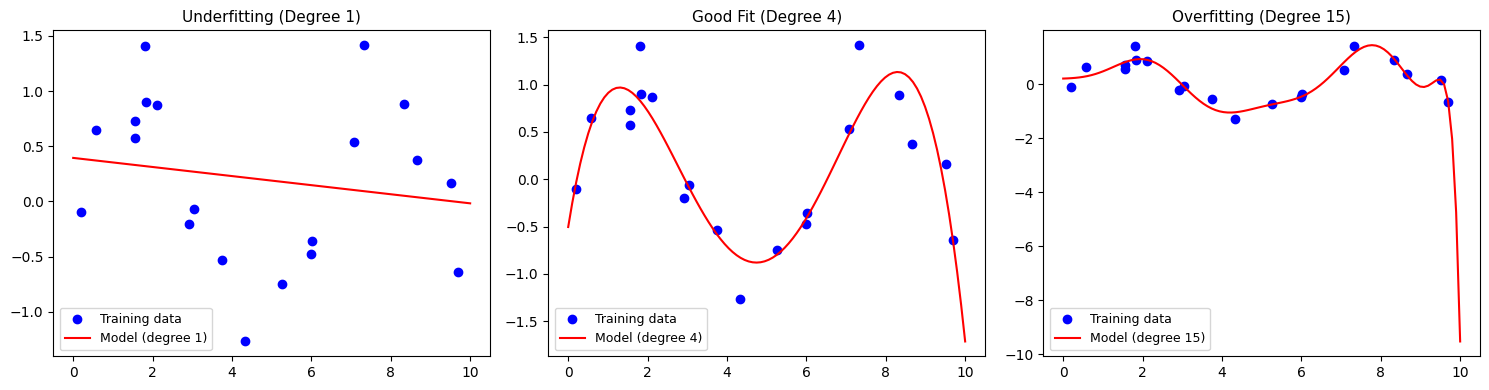

💡 Notice: The rightmost model perfectly fits training points but misses the true pattern!


In [4]:
# Demonstrating Overfitting with Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Generate simple data with noise
np.random.seed(42)
X_simple = np.sort(np.random.rand(20, 1) * 10, axis=0)
y_simple = np.sin(X_simple).ravel() + np.random.randn(20) * 0.3

# Test on new points
X_test_simple = np.linspace(0, 10, 100).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
degrees = [1, 4, 15]  # Low, Good, Overfit
titles = ['Underfitting (Degree 1)', 'Good Fit (Degree 4)', 'Overfitting (Degree 15)']

for ax, degree, title in zip(axes, degrees, titles):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_simple)
    X_test_poly = poly.transform(X_test_simple)
    
    model = LinearRegression()
    model.fit(X_poly, y_simple)
    y_pred_simple = model.predict(X_test_poly)
    
    ax.scatter(X_simple, y_simple, color='blue', label='Training data')
    ax.plot(X_test_simple, y_pred_simple, color='red', label=f'Model (degree {degree})')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("💡 Notice: The rightmost model perfectly fits training points but misses the true pattern!")

---

## 5. Why This Matters for Generative AI

Understanding these ML fundamentals is crucial because:

1. **LLMs are ML Models:** They learn patterns from massive text datasets using **self-supervised learning** — predicting the next token requires no human labels; the data labels itself

2. **Overfitting exists in LLMs:** Called "memorization" - models may reproduce training data verbatim

3. **Evaluation is Key:** Just like we evaluate classifiers with metrics, we evaluate LLMs with benchmarks like **MMLU** (knowledge), **HumanEval** (coding), and **HellaSwag** (reasoning) — perplexity measures training fit, but benchmark suites measure real-world capability

4. **Fine-tuning is Transfer Learning:** When we fine-tune an LLM on specific data, we're applying transfer learning principles

5. **Feature Engineering → Prompt Engineering:** In GenAI, how you structure your input (prompt) is like feature engineering for traditional ML

---

## 📝 Student Exercise: Build Your Own Classifier

### The Problem: Breast Cancer Diagnosis

You are going to build a machine learning model that helps doctors decide whether a breast tumor is **malignant** (cancerous) or **benign** (non-cancerous).

**Why is this a classification problem?**  
Because the answer we want is a *category*, not a number. There are exactly two possible outcomes — malignant or benign — and the model must assign each patient to one of them. This is called **binary classification**. The Iris example above was *multi-class classification* (3 categories). Same idea, scaled up.

**Why does this matter?**  
A model that correctly identifies a malignant tumor could help catch cancer early. A false negative (missing a real cancer) is far more dangerous than a false positive (flagging a benign tumor as suspicious). This is exactly why **recall** matters more than accuracy in medical applications — you now know how to measure that from the section above!

---

### The Dataset: Wisconsin Breast Cancer Dataset

Scikit-learn includes a real medical dataset: 569 patients, 30 features extracted from digitized images of breast biopsies (things like mean radius, texture, concavity of cell nuclei). Each patient is labeled as malignant or benign.

- **569 samples** (212 malignant, 357 benign)
- **30 features** — all numeric, from medical imaging
- **2 classes**: `malignant` (0) and `benign` (1)

This is a real-world dataset used in published ML research.

---

### The Standard Steps (follow these in the code below)

Every classification task follows the same workflow you saw in the Iris example. Here it is as a checklist:

```
1. Load the data          → What are we working with? How many samples? How many features?
2. Split                 → 80% for training, 20% held out for testing (never touch until the end!)
3. Scale/Preprocess      → StandardScaler so features are on the same scale
4. Choose a model        → LogisticRegression (simple, interpretable) or RandomForestClassifier (more powerful)
5. Train                 → model.fit(X_train, y_train)
6. Predict               → model.predict(X_test)
7. Evaluate              → accuracy_score, then classification_report
8. Interpret             → Use what you learned above to read the results!
```

> 💡 **Hint:** You already know all the code — it's the same pattern as the Iris example. The skill you're practicing is being able to *apply* a known pattern to a new problem. That's the core loop of data science.

**What accuracy should you expect?**
- LogisticRegression: ~95–97%
- RandomForestClassifier: ~96–98%

If you get something very different, double-check that you scaled the features before training (LogisticRegression is very sensitive to feature scale).

---

### Challenge: Once you get it working, ask yourself:
- Which class has lower recall — malignant or benign? Why might that be?
- What would be the real-world consequence of a low recall on malignant cases?
- Try switching from `LogisticRegression` to `RandomForestClassifier` — does accuracy or recall change?


In [ ]:
# Student Exercise: Complete the code below
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier  # Available for the TODO below

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

print(f"Dataset: {data.filename if hasattr(data, 'filename') else 'Breast Cancer'}")
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Classes: {data.target_names}")

# TODO: Split the data (80% train, 20% test)
# X_train, X_test, y_train, y_test = ...

# TODO: Scale the features using StandardScaler
# scaler = ...

# TODO: Train a classifier (try LogisticRegression or RandomForestClassifier)
# model = ...

# TODO: Make predictions and calculate accuracy
# accuracy = ...
# print(f"Accuracy: {accuracy:.2%}")
# Expected: ~95-97% accuracy for LogisticRegression; ~96-98% for RandomForestClassifier

# TODO: Print classification report
# from sklearn.metrics import classification_report
# print(classification_report(y_test, y_pred, target_names=data.target_names))

---

## 🎯 Key Takeaways

1. **Machine Learning** finds patterns in data rather than following explicit rules
2. **Supervised learning** needs labeled data; **unsupervised learning** discovers structure without labels
3. The ML workflow: Collect → Preprocess → Engineer Features → Train → Evaluate
4. **Overfitting** = memorizing training data instead of learning generalizable patterns
5. Always **evaluate on held-out test data** to measure true performance

---

### Next Module: Deep Learning Primer →
We'll explore neural networks - the foundation of modern generative AI!